This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-12-03 17:50:58.056756: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-03 17:50:58.057439: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-03 17:50:58.060371: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-03 17:50:58.072692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register

In [ ]:
fit=False
testing_size='07'
testing_size_f=0.07

In [9]:
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_train.csv")
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Train_set_SMOTE_noise.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,75.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,85.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,51.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,55.0


In [10]:
eigth_bins_filteres = eigth_bins#[rnaseq_genes]


In [11]:
del eigth_bins

In [12]:
seq_y_train_cat_a=eigth_bins_filteres["Age"]
seq_y_train_a = pd.Series(seq_y_train_cat_a)



dataset = eigth_bins_filteres.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,75.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,85.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,51.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,55.0


In [ ]:
class optimize:
    def __init__(self,train_data, n_trials=50):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=testing_size_f)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
    def optimize(self):
        study = optuna.create_study(direction='minimize')  # Maximize accuracy
        study.optimize(self.objective, n_trials=self.n_trials) 
    def objective(self, trial):
        # Define hyperparameters to optimize
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
            'depth': trial.suggest_int('depth', 2, 5),
            'random_state': 42,  # Fixed random state
            'verbose': 0,  # Fixed verbosity
            'od_type': 'Iter',  # Early stopping type
            'od_wait': 5,  # Early stopping patience
            #'eval_metric': 'RMSE'  # Metric to optimize

        }
        params = {
        'iterations': trial.suggest_int('iterations', 50, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),  # Modify depth range to match the original
        'verbose': 0,  # Fixed verbosity
        'od_type': 'Iter',  # Early stopping type
        'od_wait': 5,  # Early stopping patience
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
        #'model_shrink_mode': trial.suggest_categorical('model_shrink_mode', ['Constant', 'ShrinkToBest', 'ShrinkToRandom']),  # Model shrink mode
        'eval_metric': 'RMSE'  # Metric to optimize
    }

        # Initialize classifier with the suggested hyperparameters
        regressor = CatBoostRegressor(**params)

        # Fit the model
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)
        # Make predictions
        y_pred = regressor.predict(self.X_test)
        # Calculate rmse
        rmse = mean_squared_error(self.y_test, y_pred, squared=False)
        return rmse


In [14]:

if fit:
    optimize = optimize(train_data = dataset, n_trials=20)
    params = optimize.optimize()
    params

In [15]:
# [I 2024-09-25 21:18:19,700] Trial 6 finished with value: 4.733188762255442 and parameters: 
params = {'iterations': 556, 'learning_rate': 0.008352826387919279, 'depth': 3, 'l2_leaf_reg': 8.625993928282805, 'random_strength': 5.518222301454832, 'min_data_in_leaf': 37, 'score_function': 'L2', 'penalties_coefficient': 0.9978892027428243, 'model_shrink_rate': 0.03029125396360066}
#. Best is trial 6 with value: 4.733188762255442.


In [16]:
#

In [17]:
#params = {'iterations': 2000, 'learning_rate': 0.0057754728847108075, 'depth': 4, 'l2_leaf_reg': 1.4995313057538833, 'random_strength': 3.6144926272336773, 'min_data_in_leaf': 33, 'score_function': 'Cosine', 'penalties_coefficient': 7.492437722110218, 'model_shrink_rate': 0.0036095159058368662}

In [18]:
#fit=True

In [ ]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=testing_size_f)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(**params) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)

In [ ]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_556i_{testing_size}.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_556i_{testing_size}.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [66]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

19.803044454933712

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 19.803044454933712
RMSE: 4.450061174291171
MAE: 3.793253654400065
R2: 0.9609351418582965


In [68]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 3},
 {'label': '26-35', 'range': (26, 35), 'count': 4},
 {'label': '35-65', 'range': (35, 65), 'count': 3},
 {'label': '65-71', 'range': (65, 71), 'count': 1},
 {'label': '71-72', 'range': (71, 72), 'count': 1},
 {'label': '72-95', 'range': (72, 95), 'count': 5}]

In [69]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[2, 1, 0, 0, 0, 0],
       [0, 4, 0, 0, 0, 0],
       [0, 0, 3, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 2, 0, 3]])

In [70]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.7647058823529411

In [71]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.735689958019051

In [72]:
y_test

208    54.0
97     72.0
103    54.0
141    31.0
148    70.0
189    32.0
126    74.0
50     75.0
167    24.0
181    30.0
125    83.0
8      71.0
2      51.0
54     22.0
178    20.0
65     33.0
214    86.0
Name: Age, dtype: float64

In [73]:
seq_results

,Actual,Predicted
208,54.0,52.322370
97,72.0,76.234103
103,54.0,60.528349
141,31.0,27.460369
148,70.0,69.672533
189,32.0,28.018526
126,74.0,66.877984
50,75.0,69.015041
167,24.0,22.973139
181,30.0,27.795269


In [ ]:
seq_results.to_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_results_testset_556i_{testing_size}.csv")

/tmp/ipykernel_121389/756582211.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


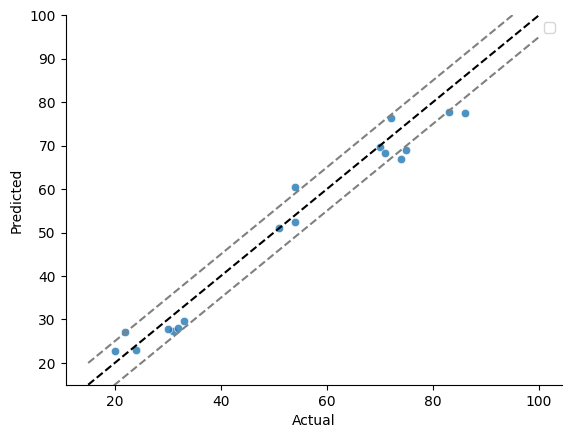

In [ ]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_scatterplot_{testing_size}.png')
plt.show()

In [74]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[2, 1, 0, 0, 0, 0],
       [0, 4, 0, 0, 0, 0],
       [0, 0, 3, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 2, 0, 3]])

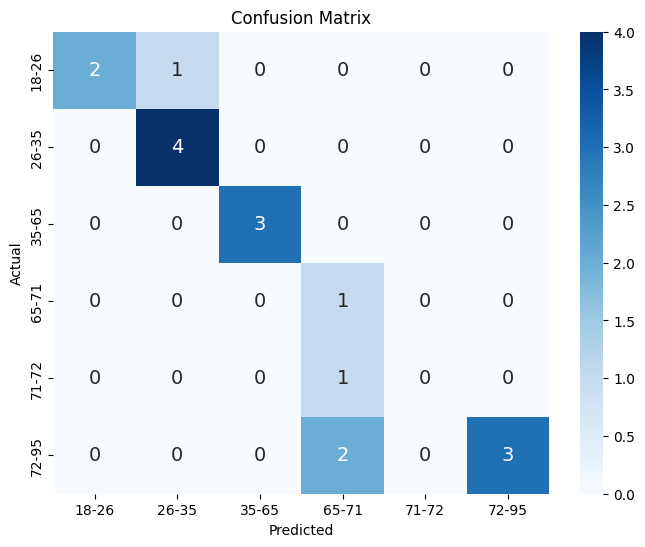

In [ ]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_confusion_matrix_{testing_size}.png')
plt.show()

In [76]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Test_set.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Status,Experiment,Age.1,Sample,Sex
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024472,-0.024526,-0.023199,-0.024432,24.0,Healthy,GSE157585,24.0,SRR12604218,NaN
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025252,-0.025311,-0.024447,-0.025087,18.0,Healthy,GSE167186,18.0,SRR13759023,NaN
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029934,-0.029985,-0.022886,-0.029776,23.0,Healthy,GSE167186,23.0,SRR13759025,NaN
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028774,-0.028772,-0.027571,-0.028812,26.4,untrained,GSE60590,26.4,SRR1555206,female
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026722,-0.026784,-0.025465,-0.026577,71.0,Healthy,GSE157585,71.0,SRR12604184,NaN


In [77]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-65', 'range': (35, 65), 'count': 17},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [78]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample", "Age.1", "Status", "Sex"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [79]:
X_test_untoached.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285458.1', 'ENSG00000285470.1', 'ENSG00000285471.1',
       'ENSG00000285472.1', 'ENSG00000285476.1', 'ENSG00000285480.1',
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1'],
      dtype='object', length=34505)

In [80]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [81]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

46.86848444246526

/tmp/ipykernel_89341/189241435.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


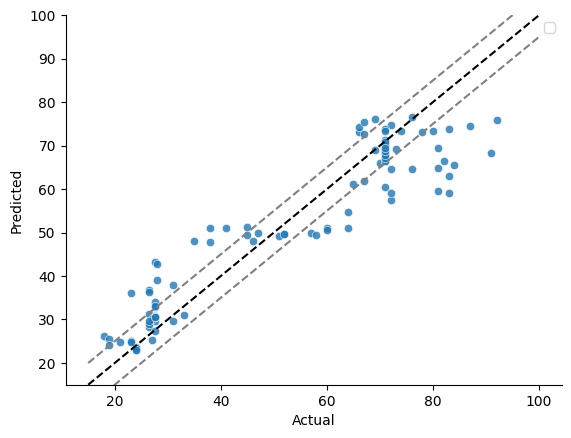

In [ ]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_untouched_set_scatterplot_{testing_size}.png')
plt.show()

In [37]:
from importlib import reload
reload(m)

<module 'model' from '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/model.py'>

     Actual  Predicted Experiment
0      24.0  23.221191  GSE157585
1      18.0  26.198732  GSE167186
2      23.0  24.289711  GSE167186
3      26.4  43.500786   GSE60590
4      71.0  68.304524  GSE157585
..      ...        ...        ...
103    71.0  70.909594  GSE157585
104    23.0  25.604365  GSE167186
105    72.0  74.574402  GSE164471
106    71.0  67.757675  GSE157585
107    71.0  75.181044  GSE167186

[108 rows x 3 columns]


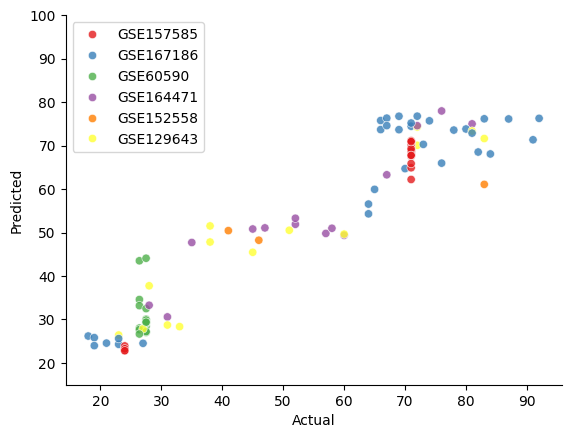

In [ ]:
m.output_directory = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Catboost"
m.plot_results(results=seq_results, labels=seq_z_test, save=True, save_output=f"catboost_regression_smote_untoached_{testing_size}.png")

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-50', 'range': (35, 50), 'count': 8},
 {'label': '50-65', 'range': (50, 65), 'count': 9},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [84]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[11,  2,  0,  0,  0,  0],
       [ 1, 19,  3,  0,  0,  0],
       [ 0,  0, 17,  0,  0,  0],
       [ 0,  0,  3,  0,  0,  6],
       [ 0,  0,  2, 20,  1,  2],
       [ 0,  0,  1,  5,  2, 13]])

In [85]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.5648148148148148

In [86]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.5054908735634912

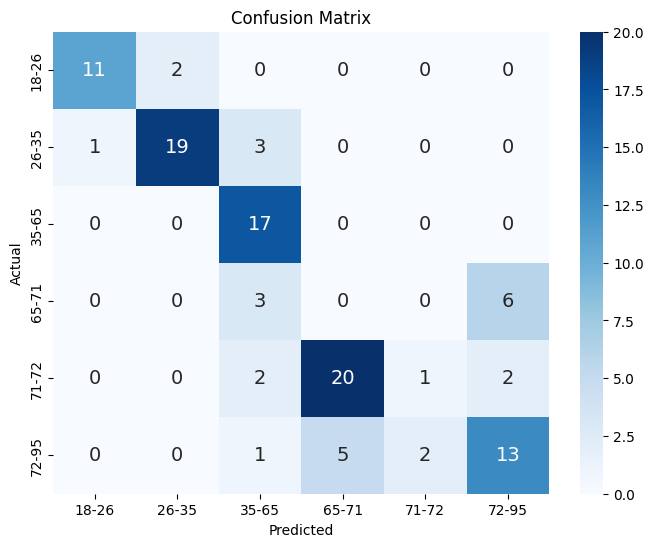

In [ ]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f"RNAseq_catboost_untoached_test_set_confusion_matrix_{testing_size}.png")
plt.show()

In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 46.86848444246526
RMSE: 6.846056123233672
MAE: 5.05377536006394
R2: 0.9063860346006213


In [105]:
explainer = shap.Explainer(seq_regressor, X_test)
shap_values = explainer.shap_values(X_test, check_additivity=False)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
NT5C2,1.413563e+01
AC012146.4,1.204186e+01
UBFD1,1.083837e+01
ALDOA.1,7.641741e+00
H3F3B,6.241443e+00
...,...
RSPRY1,5.070785e-06
RNA5SP385,2.550555e-06
TRIM24,8.830067e-07
HSP90AB1,8.377255e-07


In [ ]:
feature_imporance_path = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_{testing_size}.csv"
feature_imporance_df.to_csv(feature_imporance_path)

In [90]:
feature_imporance_df.head(50)


,importance
ENSG00000076685.18,14.135628
ENSG00000262855.1,12.041862
ENSG00000103353.15,10.838371
ENSG00000285043.1,7.641741
ENSG00000132475.10,6.241443
ENSG00000066855.15,4.300535
ENSG00000234441.1,4.168808
ENSG00000166619.12,3.897527
ENSG00000171055.14,2.825766
ENSG00000184489.11,1.917136


In [45]:
ensembl_list_file = "/home/karen/Documents/phd/Resources/ensmbl_list.csv"
ensembl_list = pd.read_csv(ensembl_list_file)

In [46]:
# remove after the point in all rows of feature_imporance_df
feature_imporance_df.index = feature_imporance_df.index.str.split(".").str[0]


In [47]:
# Create a dictionary for mapping ensembl to geneSymbol
ensembl_to_gene = dict(zip(ensembl_list["ensembl"], ensembl_list["geneSymbol"]))

# Replace the index of feature_importance_df
feature_imporance_df.index = feature_imporance_df.index.map(lambda x: ensembl_to_gene.get(x, x))
feature_imporance_df.head()

,importance
STUM,19.534839
MTFR1,9.205338
DAPK2,6.349829
FBXO31,4.661575
CA3,4.181707


In [99]:
X_test.rename(columns=lambda x: x.split(".")[0], inplace=True)

In [100]:
X_test = X_test.rename(columns=lambda x: ensembl_to_gene.get(x, x))


In [ ]:
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df
# Save the DataFrame to a CSV file
shap_df.to_csv(f"shap_values_by_gene_Catboost_{testing_size}_extended.csv", index=False)

In [ ]:
shap_values_2 = explainer(X_test, check_additivity=False)


In [3]:
shap_values_2.expected_value

NameError: name 'shap_values_2' is not defined

In [108]:
X_test

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC093827.5,AC010977.1,AC007846.2,AC134980.5,AC139491.7,AC021097.2,AC135068.11,AC010616.2,AL034430.1,AP000646.1
208,-0.020567,-0.022730,-0.004191,-0.021059,-0.021905,-0.022297,-0.018628,-0.020059,-0.019107,-0.020147,...,-0.022230,-0.022746,-0.022753,-0.022714,-0.022734,-0.022152,-0.022774,-0.022736,-0.019958,-0.022669
97,-0.027338,-0.027269,-0.002095,-0.024523,-0.025674,-0.026742,-0.017815,-0.022393,-0.020612,-0.024551,...,-0.024053,-0.027261,-0.027120,-0.027240,-0.027172,-0.026976,-0.027236,-0.027264,-0.024580,-0.027075
103,-0.024846,-0.025275,-0.001524,-0.023763,-0.023341,-0.024959,-0.019654,-0.021975,-0.019969,-0.022371,...,-0.020307,-0.025320,-0.025166,-0.025292,-0.025220,-0.025181,-0.025295,-0.025327,-0.020465,-0.025131
141,-0.021340,-0.023615,-0.006280,-0.022375,-0.023463,-0.023325,-0.020330,-0.021371,-0.022376,-0.022207,...,-0.022824,-0.023712,-0.023713,-0.023718,-0.023678,-0.023091,-0.023741,-0.023709,-0.020413,-0.023409
148,-0.025252,-0.028675,-0.001493,-0.026469,-0.026869,-0.028415,-0.020308,-0.020980,-0.024249,-0.026418,...,-0.024808,-0.028751,-0.028183,-0.028738,-0.028609,-0.028206,-0.028700,-0.028696,-0.027418,-0.028633
189,-0.019963,-0.022249,-0.005812,-0.020946,-0.021886,-0.021812,-0.017658,-0.019874,-0.018366,-0.020570,...,-0.021790,-0.022324,-0.022281,-0.022317,-0.022298,-0.021735,-0.022348,-0.022322,-0.020651,-0.022298
126,-0.030394,-0.036088,0.000360,-0.031653,-0.032475,-0.033940,-0.022340,-0.028575,-0.026454,-0.030295,...,-0.029449,-0.036148,-0.036171,-0.036138,-0.036162,-0.036370,-0.036121,-0.036105,-0.034036,-0.035953
50,-0.033073,-0.038208,0.000966,-0.033546,-0.035249,-0.037041,-0.020453,-0.024521,-0.023047,-0.032234,...,-0.030615,-0.038567,-0.038610,-0.038557,-0.038402,-0.032790,-0.038547,-0.038563,-0.036642,-0.038361
167,-0.021281,-0.023549,-0.007455,-0.023038,-0.022383,-0.023235,-0.020766,-0.021022,-0.020467,-0.022506,...,-0.019569,-0.023554,-0.023467,-0.023509,-0.023481,-0.023122,-0.023576,-0.023592,-0.021273,-0.023511
181,-0.017942,-0.021744,-0.006014,-0.020833,-0.020499,-0.021685,-0.018286,-0.018172,-0.019506,-0.020451,...,-0.018947,-0.022082,-0.022098,-0.022082,-0.022020,-0.021022,-0.022050,-0.022125,-0.019407,-0.022052


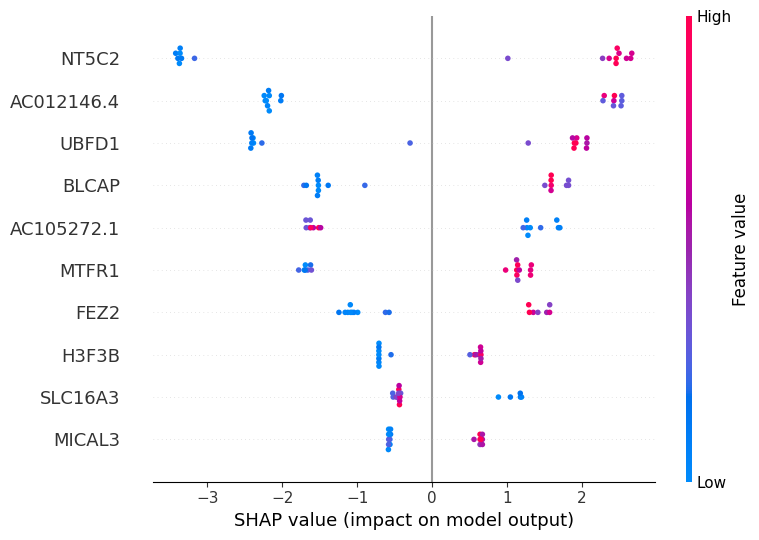

In [113]:
shap.summary_plot(shap_values, X_test, max_display=10)


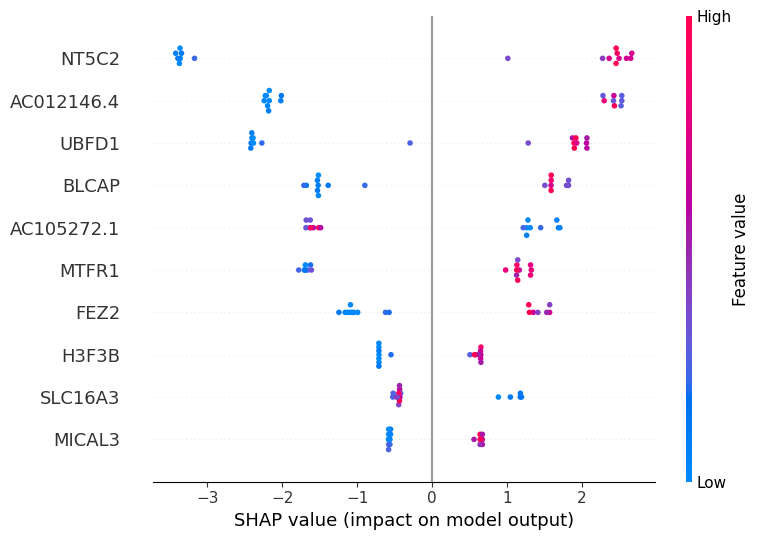

In [114]:
shap.summary_plot(shap_values_2, X_test, max_display=10)


In [1]:
index=6
title = f"Sample {index}\n {seq_results.iloc[index]}"

print(title)
shap.plots.waterfall(shap_values_2[index])


NameError: name 'seq_results' is not defined

In [95]:
shap_values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [91]:
explainer.expected_value

50.37973766069241

In [51]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.4542533038198583

In [52]:
auc = accuracy_score(c_y_test, c_y_pred)
auc

0.5092592592592593

In [53]:
reload(gtg)

<module 'getting_threshold_genes' from '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py'>

In [ ]:
# Elbow and Inflexion point
rn_df = gtg.get_gene_rank(feature_imporance_path)
rn_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_gene_ranking_{testing_size}.csv")
top_df = gtg.get_df(feature_imporance_path)
top_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_top_genes_inflexion_{testing_size}.csv")

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
1.2513913948983713


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/

In [57]:
top_df

,Ensembl,coef,abs_coef
0,ENSG00000076685.18,14.135628,14.135628
1,ENSG00000262855.1,12.041862,12.041862
2,ENSG00000103353.15,10.838371,10.838371
3,ENSG00000285043.1,7.641741,7.641741
4,ENSG00000132475.10,6.241443,6.241443
5,ENSG00000066855.15,4.300535,4.300535
6,ENSG00000234441.1,4.168808,4.168808
7,ENSG00000166619.12,3.897527,3.897527
8,ENSG00000171055.14,2.825766,2.825766
9,ENSG00000184489.11,1.917136,1.917136


In [ ]:
top_df = gtg.get_df(feature_imporance_path, inflexion=False)
top_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_top_genes_elbow_{testing_size}.csv")

1.2513913948983713


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


In [59]:
top_df

,Ensembl,coef,abs_coef
0,ENSG00000076685.18,14.135628,14.135628
1,ENSG00000262855.1,12.041862,12.041862
2,ENSG00000103353.15,10.838371,10.838371
3,ENSG00000285043.1,7.641741,7.641741
4,ENSG00000132475.10,6.241443,6.241443
5,ENSG00000066855.15,4.300535,4.300535
6,ENSG00000234441.1,4.168808,4.168808
7,ENSG00000166619.12,3.897527,3.897527
8,ENSG00000171055.14,2.825766,2.825766
9,ENSG00000184489.11,1.917136,1.917136
